In [1]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.feature as cfeature

import easygems.healpix as egh
import healpy as hp

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob

In [2]:
import dask
from dask.distributed import Client
import multiprocessing

ncpu = multiprocessing.cpu_count()
threads = 8
nworker = ncpu // threads
print(
    f"Number of CPUs: {ncpu}, number of threads: {threads}, number of workers: {nworker}"
)
client = Client(
    processes=True, threads_per_worker=threads, n_workers=nworker, memory_limit="100GB"
)
client 

Number of CPUs: 256, number of threads: 8, number of workers: 32


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 256,Total memory: 2.91 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:32993,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37273,Total threads: 8
Dashboard: http://127.0.0.1:44141/status,Memory: 93.13 GiB
Nanny: tcp://127.0.0.1:35003,


In [3]:
import dask # Distributed data libary
import dask.distributed
import multiprocessing
from subprocess import run, PIPE
import warnings
warnings.filterwarnings(action='ignore')
import pandas as pd
dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})

# basic
from pathlib import Path # Object oriented libary to deal with paths
from dask.utils import format_bytes
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources

## Functions

In [4]:
def time_mean_imerg_multi(file,lat,lon,environ):
    ##Funtion to calculate the climatology monthly mean of precipitation from IMERG
    ###the environ option mask the values over land or ocean:
        ## if environ = 'trop' -> no mask is used
        ## if environ = 'ocean' -> return only values over ocean
        ## if environ = 'land' -> return only values over land
    data = xr.open_mfdataset(
        file, combine='by_coords',engine='netcdf4',chunks=({'time':20}))['calibrated_precipitation']
    if environ == 'trop':
        pr=data.sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
    else:
        lsmask01 = mask_cal(data)
        if environ == 'ocean':
            pr=data.where(lsmask01<0).sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
        elif environ == 'land':
            pr=data.where(lsmask01>0).sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
        else:
            return print('Something is wrong')
    
    prmon = pr.resample(time='1MS').mean(dim='time')
    prmon_clim = prmon.groupby('time.month').mean(dim='time')
    
    jobs = dask.persist(prmon) # prmon_clim (month, lat, lon) for the mean/ prmon (year, month, lat, lon) for the std
    progress(jobs, notebook=False)
    precip = dask.compute(prmon) # prmon_clim
    
    return precip[0]

In [5]:
def mask_cal(dset):
    ##This function calculate the land_sea mask according to the resolution of the data##
    ###negative values is ocean, positive values is land
    filemask = '/work/mh0731/from_Mistral/mh0731/m300876/land_sea_mask/GPM_IMERG_LandSeaMask.2.nc4'
    dsetmask = xr.open_dataset(filemask)
    lsmask01 = dsetmask.landseamask.where(
        dsetmask.landseamask<100).interp(lon=dset.lon.values,lat=dset.lat.values,method='linear') *0 +2
    lsmask01 = lsmask01.where(lsmask01==2,-2)
    return lsmask01

# ICON Datasets

In [6]:
import xarray as xr
path_data = "/work/mh0287/m301120/dataset/icon_r2b8_xspies_production/output_data.zarr/P1D_point_z6/"
print(f"Reading data from: {path_data}")
try:
    ds = xr.open_dataset(path_data, engine="zarr", consolidated=False)
    print("Dataset loaded successfully!")
except Exception as e:
    print(f"Failed to load dataset: {e}")
    raise
var_name = 'ocean_frac_mask_sfc'
if var_name in ds:
    ocean_frac_mask_sfc_data = ds[var_name]
    print(f"\nVariable '{var_name}' found:")
    print(ocean_frac_mask_sfc_data)
else:
    print(f"Variable '{var_name}' not found in this dataset.")

Reading data from: /work/mh0287/m301120/dataset/icon_r2b8_xspies_production/output_data.zarr/P1D_point_z6/
Dataset loaded successfully!

Variable 'ocean_frac_mask_sfc' found:
<xarray.DataArray 'ocean_frac_mask_sfc' (cell: 49152)> Size: 197kB
[49152 values with dtype=float32]
Dimensions without coordinates: cell
Attributes:
    hiopy::interpolation_stack:  [conservative: {partial_coverage: true}, fix...
    _ARRAY_DIMENSIONS:           ['cell']
    grid_mapping:                crs
    hiopy::nnn:                  4
    hiopy::enable:               True


In [7]:
import xarray as xr
path_data = "/work/mh0287/m301120/dataset/icon_r2b8_xspies_production/output_data.zarr/P1D_point_z6/"
print(f"Reading data from: {path_data}")
try:
    ds = xr.open_dataset(path_data, engine="zarr", consolidated=False)
    print("Dataset loaded successfully!")
except Exception as e:
    print(f"Failed to load dataset: {e}")
    raise
var_name = 'pr'
if var_name in ds:
    pr_data = ds[var_name]
    print(f"\nVariable '{var_name}' found:")
    print(pr_data)
else:
    print(f"Variable '{var_name}' not found in this dataset.")

Reading data from: /work/mh0287/m301120/dataset/icon_r2b8_xspies_production/output_data.zarr/P1D_point_z6/
Dataset loaded successfully!

Variable 'pr' found:
<xarray.DataArray 'pr' (time: 425, cell: 49152)> Size: 84MB
[20889600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-02 2020-01-03 ... 2021-03-01
Dimensions without coordinates: cell
Attributes:
    hiopy::interpolation_stack:  [average, fixed: {user_value: NAN}]
    _ARRAY_DIMENSIONS:           ['time', 'cell']
    grid_mapping:                crs
    hiopy::time_method:          point
    hiopy::nnn:                  4
    hiopy::enable:               True
    standard_name:               pr
    units:                       kg m-2 s-1
    short_name:                  
    long_name:                   precipitation flux


# Add coordinates

In [8]:
def get_healpix_coords(ds, nest=True, lon_convention="-180_180"):
    if 'ncells' in ds.dims: dim_name = 'ncells'
    elif 'cell' in ds.dims: dim_name = 'cell'
    else: raise ValueError("Unable to locate the spatial dimension")
    
    npix = ds.sizes[dim_name]
    nside = int(round((npix / 12) ** 0.5))
    if 12 * nside * nside != npix:
        raise ValueError(f"npix={npix} is not a valid HEALPix npix (12*nside^2).")
    
    theta, phi = hp.pix2ang(nside, np.arange(npix), nest=nest)
    lat = 90.0 - np.degrees(theta)
    lon=np.degrees(phi)
    if  lon_convention == "-180_180":
        lon = (lon + 180) % 360 - 180
    elif lon_convention == "0_360":
        lon = lon % 360
    else:
        raise ValueError("lon_convention must be '-180_180' or '0_360'")

    return lon, lat, dim_name

In [9]:
oland_lon, oland_lat, dim_oland = get_healpix_coords(ocean_frac_mask_sfc_data, nest=True, lon_convention="-180_180")

In [10]:
pr_lon, pr_lat, dim_pr = get_healpix_coords(pr_data, nest=True, lon_convention="-180_180")

In [11]:
# attach as coordinates along the ncells/cell dimension
ocean_frac_mask_sfc_data = ocean_frac_mask_sfc_data.assign_coords(
    lon=(dim_oland, oland_lon),
    lat=(dim_oland, oland_lat),
)

# (optional) add attrs
ocean_frac_mask_sfc_data["lon"].attrs.update(units="degrees_east", standard_name="longitude")
ocean_frac_mask_sfc_data["lat"].attrs.update(units="degrees_north", standard_name="latitude")

In [12]:
# attach as coordinates along the ncells/cell dimension
pr_data = pr_data.assign_coords(
    lon=(dim_pr, pr_lon),
    lat=(dim_pr, pr_lat),
)

# (optional) add attrs
pr_data["lon"].attrs.update(units="degrees_east", standard_name="longitude")
pr_data["lat"].attrs.update(units="degrees_north", standard_name="latitude")

### Tropics

In [13]:
def tropics(ds):
    return np.abs(ds.lat) <= 30.1

In [14]:
# Tropics 
pr_tropic = pr_data.where(tropics(pr_data)).drop(('lat','lon'))

In [15]:
ocean_frac_mask_sfc_tropic = ocean_frac_mask_sfc_data.where(tropics(ocean_frac_mask_sfc_data)).drop(('lat','lon'))

### Convert into lat/lon

In [16]:
def get_nn_lon_lat_index(nside, lons, lats):
    lons2, lats2 = np.meshgrid(lons, lats)
    return xr.DataArray(
        hp.ang2pix(nside, lons2, lats2, nest=True, lonlat=True),
        coords=[("lat", lats), ("lon", lons)],
    )

In [17]:
idx = get_nn_lon_lat_index(
    2**6, np.linspace(-180, 180, 3600), np.linspace(-30, 30, 601)
)

In [18]:
pr_tropic_lon_lat = pr_tropic.isel(cell=idx)

In [19]:
land_mask_lon_lat = ocean_frac_mask_sfc_tropic.isel(cell=idx)

In [20]:
pr_tropic_lon_lat = pr_tropic_lon_lat.compute()

In [21]:
land_mask_lon_lat = land_mask_lon_lat.compute()

# land, ocean, tropical

In [22]:
land_mask = land_mask_lon_lat == 0
ocean_mask = land_mask_lon_lat > 0

In [23]:
pr_tropical_land  = pr_tropic_lon_lat.where(land_mask, drop=True)
pr_tropical_ocean = pr_tropic_lon_lat.where(ocean_mask, drop=True)

# 1) Precipitation: IMERG data (2001-2021)

In [24]:
#Define a global pattern to find the files
glob_pattern_3d1 = 'IMERG_precipitationrate_V06B_daily_0.1degree_tropics_30S_30N_'
## Define the paths
data_path1 = Path('/work/mh0731/from_Mistral/mh0731/m300876/precip_paper/data/obs/IMERG')
## Collect all file names with pathlib's rglob and list compression  
file_imerg = sorted([str(f) for f in data_path1.rglob(f'*{glob_pattern_3d1}*.nc')])[:]

In [25]:
imerg_tropic = time_mean_imerg_multi(file_imerg,[-30,30],[-180,180],'trop') 

In [26]:
imerg_land= time_mean_imerg_multi(file_imerg,[-30,30],[-180,180],'land') 

In [27]:
imerg_ocean= time_mean_imerg_multi(file_imerg,[-30,30],[-180,180],'ocean') 

In [28]:
imerg_tropic = imerg_tropic.sel(time=slice("2020-01-01", "2021-03-01"))
imerg_land = imerg_land.sel(time=slice("2020-01-01", "2021-03-01"))
imerg_ocean = imerg_ocean.sel(time=slice("2020-01-01", "2021-03-01"))

## Spatial Pattern

In [87]:
pr_tropic_lon_lat_tavg = pr_tropic_lon_lat.mean(dim='time') * 86400 

In [88]:
imerg_tropic_tavg = imerg_tropic.mean(dim='time')

In [89]:
imerg_tropic_tavg_interp = imerg_tropic_tavg.interp(lat=pr_tropic_lon_lat_tavg.lat, lon=pr_tropic_lon_lat_tavg.lon)
#imerg_mult_amz = imerg_mult_SA_int.where(ABinterp_biome_imerg==0, np.nan).sel(lon=slice(-82,-30), lat=slice(-30,13))

In [90]:
diff_pr = pr_tropic_lon_lat_tavg - imerg_tropic_tavg_interp

In [91]:
def colormap_create(cmap, cnumber, loc_boundary_low, loc_boundary_high):
    get_cmap = cm.get_cmap(cmap,cnumber) 
    cmap_edit = get_cmap(np.linspace(0,1,cnumber))
    white = np.array([255/256, 255/256, 255/256, 1])
    cmap_edit[loc_boundary_low:loc_boundary_high] = white
    cmap_new = matplotlib.colors.ListedColormap(cmap_edit)
    return cmap_new

In [92]:
BrBG_new = colormap_create('BrBG',21,10,11)
Blues_new = colormap_create('Blues',21,0,1)

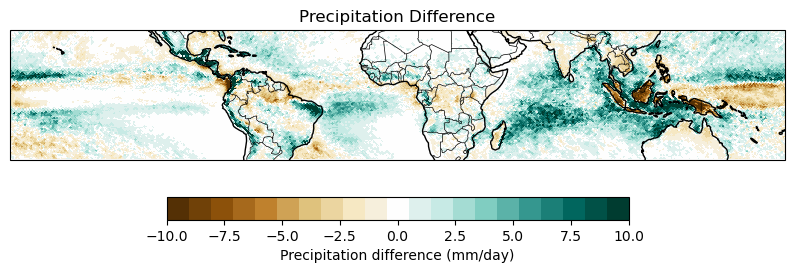

In [65]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 6))

ax = plt.axes(projection=ccrs.PlateCarree())

# Plot without automatic colorbar
im = diff_pr.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=BrBG_new,
    add_colorbar=False,
    vmin=-10, vmax=10,
)

ax.coastlines(resolution="110m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Add horizontal colorbar below
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.08,      # distance from plot
    fraction=0.05  # thickness of colorbar
)

cbar.set_label("Precipitation difference (mm/day)")

plt.title("Precipitation Difference")
plt.show()

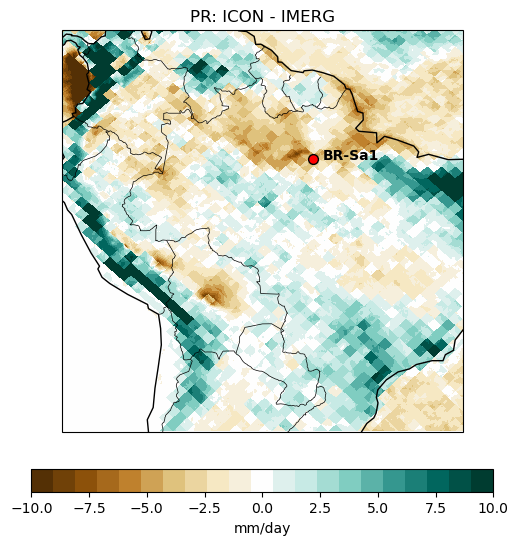

In [99]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 6))

ax = plt.axes(projection=ccrs.PlateCarree())

# Plot precipitation difference
im = diff_pr.sel(lon=slice(-80,-40), lat=slice(-30,10)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=BrBG_new,
    add_colorbar=False,
    vmin=-10, vmax=10,
)

ax.coastlines(resolution="110m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# ---- ADD YOUR POINT HERE ----
lat_point = -2.8567
lon_point = -54.9589

ax.scatter(
    lon_point,
    lat_point,
    color="red",
    s=50,                  # size of dot
    edgecolor="black",
    transform=ccrs.PlateCarree(),
    zorder=5
)

# Optional: add label
ax.text(
    lon_point + 1,
    lat_point,
    "BR-Sa1",
    transform=ccrs.PlateCarree(),
    fontsize=10,
    weight="bold"
)

# Add horizontal colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.08,
    fraction=0.05
)

cbar.set_label("mm/day")

plt.title("PR: ICON - IMERG")
plt.show()

# interpolation to cells

In [26]:
import numpy as np
import xarray as xr
from scipy.spatial import cKDTree

def lonlat_to_xyz(lon_deg, lat_deg): # sphere equation
    lon = np.deg2rad(lon_deg)
    lat = np.deg2rad(lat_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.column_stack([x, y, z])

def cell_masks(ds_cell, lat_lim=30, ocean_frac=None, land_thresh=0.5):
    trop = np.abs(ds_cell["lat"]) <= lat_lim
    if ocean_frac is None:
        return trop, None, None
    land = ocean_frac < land_thresh
    ocean = ~land
    return trop, land, ocean

def area_mean_cell(da_cell, mask_cell=None, area=None, dim="cell"):
    if mask_cell is not None:
        da_cell = da_cell.where(mask_cell)
        if area is not None:
            area = area.where(mask_cell)

    if area is None:
        return da_cell.mean(dim=dim, skipna=True)
    return (da_cell * area).sum(dim=dim, skipna=True) / area.sum(dim=dim, skipna=True)

def build_cru_tree(cru_lat, cru_lon):
    # make 2D grid points (lat, lon) -> 1D list
    lon2d, lat2d = np.meshgrid(cru_lon.values, cru_lat.values)
    pts_xyz = lonlat_to_xyz(lon2d.ravel(), lat2d.ravel())
    return cKDTree(pts_xyz), lon2d.shape

def remap_cru_to_cells_nearest(cru_da, cell_lon, cell_lat, tree, grid_shape):
    """
    cru_da: DataArray (time, lat, lon) or (lat, lon)
    returns: DataArray with dim 'cell' (and time if present)
    """
    cell_xyz = lonlat_to_xyz(cell_lon.values, cell_lat.values)
    _, idx = tree.query(cell_xyz, k=1)

    nlat, nlon = grid_shape
    iy = idx // nlon
    ix = idx %  nlon

    # advanced indexing using isel with DataArray indexers
    iy_da = xr.DataArray(iy, dims=("cell",))
    ix_da = xr.DataArray(ix, dims=("cell",))

    out = cru_da.isel(lat=iy_da, lon=ix_da)
    out = out.assign_coords(cell=("cell", np.arange(cell_lon.size)))
    return out


In [27]:
# pick a level / variable for comparison
icon_t = pr_data # (original: time, cell)

# make sure time is monthly and compute climatology
# if time is daily: resample first; if already monthly, you can skip resample
icon_t_month = icon_t.resample(time="1MS").mean("time", skipna=True)
icon_t_clim  = icon_t_month.groupby("time.month").mean("time", skipna=True)

# masks on cell grid
trop_mask, land_mask, ocean_mask = cell_masks(
    pr_data, lat_lim=30,
    ocean_frac=ocean_frac_mask_sfc_data,  # (cell)
    land_thresh=0.5
)

# Optional area weights if you have them:
# area = tas_data["cell_area"]  # or a separate array
area = None

### Land

In [28]:
icon_trop_land_mean = area_mean_cell(icon_t_clim, mask_cell=(trop_mask & land_mask), area=area, dim="cell")
# convert to mm/day
icon_trop_land_mean_c = icon_trop_land_mean * 3600 * 24

In [29]:
# build KDTree once
tree, grid_shape = build_cru_tree(imerg_tropic.lat, imerg_tropic.lon)

# remap CRU climatology (month, lat, lon) -> (month, cell)
cru_on_cells = remap_cru_to_cells_nearest(
    imerg_tropic, pr_data["lon"], pr_data["lat"], tree, grid_shape
)

# apply the exact same tropical-land cell mask
cru_trop_land_mean = area_mean_cell(cru_on_cells, mask_cell=(trop_mask & land_mask), area=area, dim="cell")
cru_trop_land_tmean = cru_trop_land_mean.resample(time="1MS").mean("time", skipna=True)
cru_trop_land_tmean_month = cru_trop_land_tmean.groupby("time.month").mean("time", skipna=True)

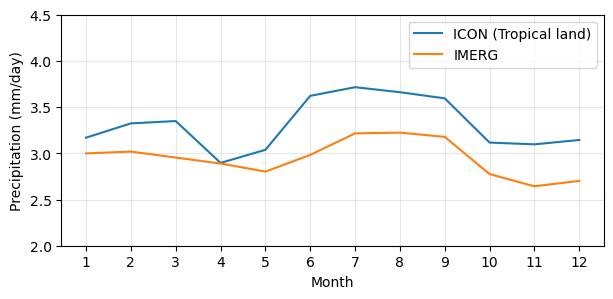

In [85]:
import matplotlib.pyplot as plt

months = np.arange(1,13)

plt.figure(figsize=(7,3))
plt.plot(months, icon_trop_land_mean_c.values, label="ICON (Tropical land)")
plt.plot(months, cru_trop_land_tmean_month.values, label="IMERG")
plt.xticks(months)
plt.ylim(2,4.5)
plt.xlabel("Month")
plt.ylabel("Precipitation (mm/day)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Ocean

In [86]:
icon_trop_ocean_mean = area_mean_cell(icon_t_clim, mask_cell=(trop_mask & ocean_mask), area=area, dim="cell")
# convert to mm/day
icon_trop_ocean_mean_c = icon_trop_ocean_mean * 3600 * 24

In [87]:
# apply the exact same tropical-ocean cell mask
cru_trop_ocean_mean = area_mean_cell(cru_on_cells, mask_cell=(trop_mask & ocean_mask), area=area, dim="cell")
cru_trop_ocean_tmean = cru_trop_ocean_mean.resample(time="1MS").mean("time", skipna=True)
cru_trop_ocean_tmean_month = cru_trop_ocean_tmean.groupby("time.month").mean("time", skipna=True)

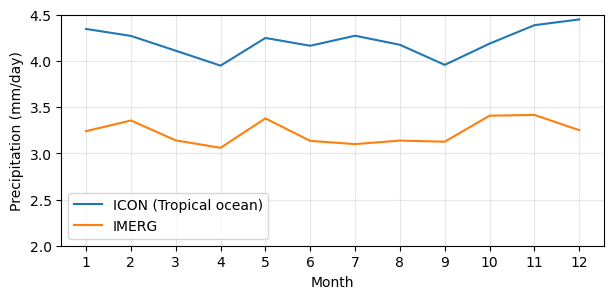

In [88]:
import matplotlib.pyplot as plt

months = np.arange(1,13)

plt.figure(figsize=(7,3))
plt.plot(months, icon_trop_ocean_mean_c.values, label="ICON (Tropical ocean)")
plt.plot(months, cru_trop_ocean_tmean_month.values, label="IMERG")
plt.xticks(months)
plt.ylim(2,4.5)
plt.xlabel("Month")
plt.ylabel("Precipitation (mm/day)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Tropics

In [89]:
icon_trop_mean = area_mean_cell(icon_t_clim, mask_cell=trop_mask, area=area, dim="cell")
# convert to mm/day
icon_trop_mean_c = icon_trop_mean * 3600 * 24

In [90]:
# apply the exact same tropical-ocean cell mask
cru_trop_mean = area_mean_cell(cru_on_cells, mask_cell=trop_mask, area=area, dim="cell")
cru_trop_tmean = cru_trop_mean.resample(time="1MS").mean("time", skipna=True)
cru_trop_tmean_month = cru_trop_tmean.groupby("time.month").mean("time", skipna=True)

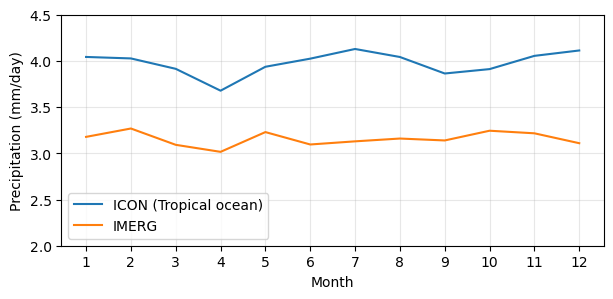

In [91]:
import matplotlib.pyplot as plt

months = np.arange(1,13)

plt.figure(figsize=(7,3))
plt.plot(months, icon_trop_mean_c.values, label="ICON (Tropical ocean)")
plt.plot(months, cru_trop_tmean_month.values, label="IMERG")
plt.xticks(months)
plt.ylim(2,4.5)
plt.xlabel("Month")
plt.ylabel("Precipitation (mm/day)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Object detection: using datasets (time, lat, lon) over land only!

_ICON_

In [75]:
# ICON
pr_tropical_land_month = pr_tropical_land.groupby('time.month').mean('time')
pr_land_q80 = pr_tropical_land_month.quantile(0.8,dim=('lon','lat'))

_IMERG_

In [74]:
# IMERG
pr_imerg_land_month = imerg_land.groupby('time.month').mean('time')
pr_imerg_land_q80 = pr_imerg_land_month.quantile(0.8,dim=('lon','lat'))

### Functions

In [66]:
def calc_area(data,dx,dy):
    ##Calculate the area of each grid cell in the data
    earthr = 6.371e6
    loncmorph,latcmorph = np.meshgrid(data.lon.values,data.lat.values)
    area = xr.DataArray(data = (dx/180*np.pi)*earthr*np.cos(latcmorph/180*np.pi)*(dy/180*np.pi)*earthr,
                            dims=["lat","lon"],
                            coords=dict(
                            lat=(["lat"],data.lat.values),
                            lon=(["lon"],data.lon.values),))
    return area

In [67]:
def calc_objects(data,threshold,structure):
    ## This function calculates the objects of precipitation according to a threshold and a strcuture
    labels,num = measurements.label(data.where(data>threshold,0),structure=structure)
    ###sorting labels according to index
    labelsu = np.unique(labels);
    labels_n = np.searchsorted(labelsu,labels); 
    indices_n = np.arange(np.max(labels_n)+1);
    return labels_n,indices_n

In [68]:
def cal_statistic(data,area_grid,labels_n,indices_n,threshold):
    ## This function calculates the statistics of the objects as: 
        ##area 
        ##mean precipitation
        ##centroid (longitude and latitude)
    sum_area=ndimage.sum(area_grid,labels_n,indices_n)
    meanp = ndimage.mean((data).where(data>threshold,0),labels_n,indices_n)
    meanp_area = (ndimage.mean(data,labels_n,indices_n)/(ndimage.sum(area_grid,labels_n,indices_n)))
    centr_lat = [data.lat.values[int(ndimage.center_of_mass((data),labels_n,indices_n)[j][0])] for j in range(
        len(indices_n))]
    centr_lon = [data.lon.values[int(ndimage.center_of_mass((data),labels_n,indices_n)[j][1])] for j in range(
        len(indices_n))]
    
    stats  = np.zeros((5,len(indices_n)))
    stats[0,:] = sum_area
    stats[1,:] = meanp
    stats[2,:] = meanp_area
    stats[3,:] = centr_lat
    stats[4,:] = centr_lon
    
    return meanp, sum_area, stats

In [69]:
def cal_max_object(data,stats,labels_n,indices_n,sum_area,meanp,threshold,area_min):
    ##This function caluclates the object with the maximum area 
    sel_ind = indices_n[(meanp>threshold) & (sum_area/1000000>(area_min))]
    nstats = [stats[:,indices_n==sel_ind[i]] for i in range(len(sel_ind))]
    nlabel = [np.where(labels_n==sel_ind[i], data, np.nan) for i in range(len(sel_ind))]
    
    if not sel_ind.any():
        nstats = [np.zeros((5,1))*np.nan]
        return nstats,nlabel
    elif len(sel_ind) == 1:
        return nstats,nlabel
    else:
        area = [nstats[i][0] for i in range(len(sel_ind))]
        max_tuple = max(area, key=lambda x:x[0])
        max_ind = area.index(max_tuple)

        return [nstats[max_ind]], [nlabel[max_ind]]

In [70]:
def object_id(data,dx,dy,structure,threshold,area_min):
    ####create area
    area_grid = calc_area(data,dx,dy) 
    ###calculating objects
    labels_n,indices_n = calc_objects(data,threshold,structure)
    
    ###calculate stats
    meanp, sum_area, stats = cal_statistic(data,area_grid,labels_n,indices_n,threshold)

    ###selecting only the according to the classification 
    return cal_max_object(data,stats,labels_n,indices_n,sum_area,meanp,threshold,area_min)

In [76]:
s = ndimage.generate_binary_structure(2,2)

### South America

In [78]:
pr_tropical_land_month_nonan = pr_tropical_land_month.where(pr_tropical_land_month>=0,0)

In [79]:
##ICON-S
sam_stats =  [object_id(pr_tropical_land_month_nonan[i,:,:].sel(lat=slice(-30,13),lon=slice(-82,-30)),0.1,0.1,s,\
                                     pr_land_q80[i].values,[500*500]) for i in range(pr_land_q80.size)]

In [81]:
pr_imerg_land_month_nonan = pr_imerg_land_month.where(pr_imerg_land_month>=0,0)

In [82]:
##IMERG
sam_stats_imerg =  [object_id(pr_imerg_land_month_nonan[i,:,:].sel(lat=slice(-30,13),lon=slice(-82,-30)),0.1,0.1,s,\
                                     pr_imerg_land_q80[i].values,[500*500]) for i in range(pr_imerg_land_q80.size)]

In [85]:
sam_area_ctl = [sam_stats[i][0][0][0] for i in range(pr_land_q80.size)]
sam_loni_ctl = [sam_stats[i][0][0][-1] for i in range(pr_land_q80.size)]
sam_lati_ctl = [sam_stats[i][0][0][-2] for i in range(pr_land_q80.size)]
sam_intensity_ctl = [sam_stats[i][0][0][2] for i in range(pr_land_q80.size)]
sam_precip_ctl = [sam_stats[i][0][0][1] for i in range(pr_land_q80.size)]

In [86]:
sam_area_imerg = [sam_stats_imerg[i][0][0][0] for i in range(pr_land_q80.size)]
sam_loni_imerg = [sam_stats_imerg[i][0][0][-1] for i in range(pr_land_q80.size)]
sam_lati_imerg = [sam_stats_imerg[i][0][0][-2] for i in range(pr_land_q80.size)]
sam_intensity_imerg = [sam_stats_imerg[i][0][0][2] for i in range(pr_land_q80.size)]
sam_precip_imerg = [sam_stats_imerg[i][0][0][1] for i in range(pr_land_q80.size)]

In [95]:
sam_area_ctl_concat = np.concatenate(sam_area_ctl)
sam_area_imerg_concat = np.concatenate(sam_area_imerg)

_Africa_

In [98]:
afr_stats =  [object_id(pr_tropical_land_month_nonan[i,:,:].sel(lat=slice(-30,25),lon=slice(-20,45)),0.1,0.1,s,\
                                     pr_land_q80[i].values,[500*500]) for i in range(pr_land_q80.size)]

In [99]:
afr_stats_imerg =  [object_id(pr_imerg_land_month_nonan[i,:,:].sel(lat=slice(-30,25),lon=slice(-20,45)),0.1,0.1,s,\
                                     pr_imerg_land_q80[i].values,[500*500]) for i in range(pr_imerg_land_q80.size)]

In [100]:
afr_area_ctl = [afr_stats[i][0][0][0] for i in range(pr_land_q80.size)]
afr_loni_ctl = [afr_stats[i][0][0][-1] for i in range(pr_land_q80.size)]
afr_lati_ctl = [afr_stats[i][0][0][-2] for i in range(pr_land_q80.size)]
afr_intensity_ctl = [afr_stats[i][0][0][2] for i in range(pr_land_q80.size)]
afr_precip_ctl = [afr_stats[i][0][0][1] for i in range(pr_land_q80.size)]

In [101]:
afr_area_imerg = [afr_stats_imerg[i][0][0][0] for i in range(pr_land_q80.size)]
afr_loni_imerg = [afr_stats_imerg[i][0][0][-1] for i in range(pr_land_q80.size)]
afr_lati_imerg = [afr_stats_imerg[i][0][0][-2] for i in range(pr_land_q80.size)]
afr_intensity_imerg = [afr_stats_imerg[i][0][0][2] for i in range(pr_land_q80.size)]
afr_precip_imerg = [afr_stats_imerg[i][0][0][1] for i in range(pr_land_q80.size)]

In [102]:
afr_area_ctl_concat = np.concatenate(afr_area_ctl)
afr_area_imerg_concat = np.concatenate(afr_area_imerg)

_India_

In [103]:
sasi_stats =  [object_id(pr_tropical_land_month_nonan[i,:,:].sel(lat=slice(10,30),lon=slice(70,90)),0.1,0.1,s,\
                                     pr_land_q80[i].values,[500*500]) for i in range(pr_land_q80.size)]

In [104]:
sasi_stats_imerg =  [object_id(pr_imerg_land_month_nonan[i,:,:].sel(lat=slice(10,30),lon=slice(70,90)),0.1,0.1,s,\
                                     pr_imerg_land_q80[i].values,[500*500]) for i in range(pr_imerg_land_q80.size)]

In [105]:
sasi_area_ctl = [sasi_stats[i][0][0][0] for i in range(pr_land_q80.size)]
sasi_loni_ctl = [sasi_stats[i][0][0][-1] for i in range(pr_land_q80.size)]
sasi_lati_ctl = [sasi_stats[i][0][0][-2] for i in range(pr_land_q80.size)]
sasi_intensity_ctl = [sasi_stats[i][0][0][2] for i in range(pr_land_q80.size)]
sasi_precip_ctl = [sasi_stats[i][0][0][1] for i in range(pr_land_q80.size)]

In [106]:
sasi_area_imerg = [sasi_stats_imerg[i][0][0][0] for i in range(pr_land_q80.size)]
sasi_loni_imerg = [sasi_stats_imerg[i][0][0][-1] for i in range(pr_land_q80.size)]
sasi_lati_imerg = [sasi_stats_imerg[i][0][0][-2] for i in range(pr_land_q80.size)]
sasi_intensity_imerg = [sasi_stats_imerg[i][0][0][2] for i in range(pr_land_q80.size)]
sasi_precip_imerg = [sasi_stats_imerg[i][0][0][1] for i in range(pr_land_q80.size)]

In [107]:
sasi_area_ctl_concat = np.concatenate(sasi_area_ctl)
sasi_area_imerg_concat = np.concatenate(sasi_area_imerg)

# Plotting

In [92]:
colors = ['darkblue','darkblue','darkcyan','darkcyan','green','green','orange','orange','red','red','brown','brown']
colors_name = ['darkblue','darkcyan','green','orange','red','brown']

In [90]:
import matplotlib.colors as mcolors
import matplotlib as mpl
# Create a colormap from lightgrey to black
cmap = mcolors.LinearSegmentedColormap.from_list("grey_to_black", ["lightgrey", "black"])

# Sample 12 evenly spaced colors
grey_colors = [cmap(i) for i in np.linspace(0, 1, 12)]

In [93]:
cmaps = (mpl.colors.ListedColormap(colors_name))
bounds = [1, 2, 3, 4, 5, 6, 7]
norms = mpl.colors.BoundaryNorm(bounds, cmaps.N)

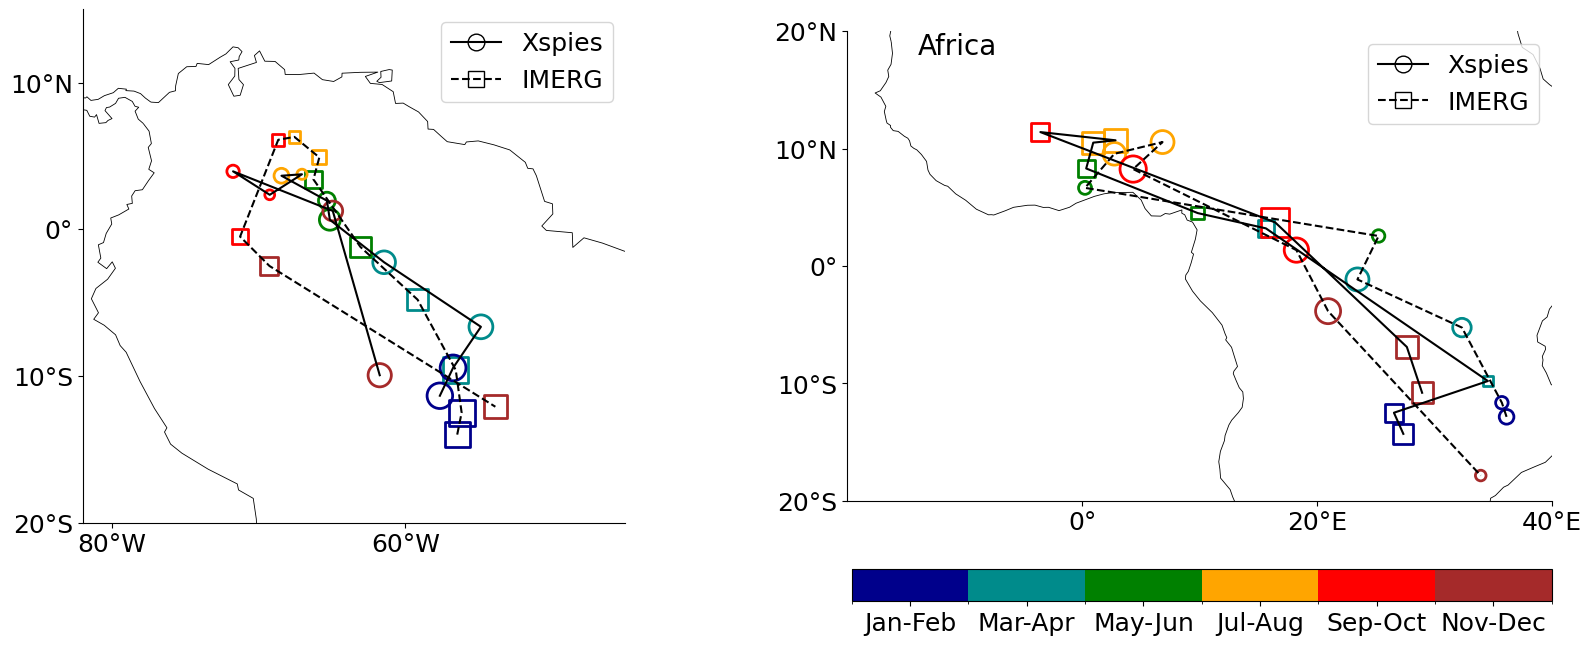

In [110]:
fig = plt.figure(figsize=(20, 16))
ax1=fig.add_axes([0.55,0.51,0.35,0.02])
###South America
ax = fig.add_subplot(221,projection=ccrs.PlateCarree(central_longitude=0))
cs1 = ax.scatter(sam_loni_ctl,sam_lati_ctl,s=sam_area_ctl_concat/sam_area_ctl_concat.mean()*200,facecolors='none',marker='s',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax.plot(sam_loni_ctl,sam_lati_ctl,'--k',transform=ccrs.PlateCarree())
cs1_2 = ax.scatter(sam_loni_imerg,sam_lati_imerg,s=sam_area_imerg_concat/sam_area_imerg_concat.mean()*200,facecolors='none',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax.plot(sam_loni_imerg,sam_lati_imerg,'-k',transform=ccrs.PlateCarree())
ax.coastlines(resolution='110m',linewidth=0.6)
ax.set_extent([-82,-45, -20, 15], crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-20,16,10),crs=ccrs.PlateCarree());lat_formatter = LatitudeFormatter();ax.yaxis.set_major_formatter(lat_formatter)
ax.set_xticks(np.arange(-80,-44,20),crs=ccrs.PlateCarree());lon_formatter = LongitudeFormatter();ax.xaxis.set_major_formatter(lon_formatter)
ax.tick_params(labelsize=18)

ax.spines['geo'].set_visible(False)
ax.spines['left'].set_visible(True)  
ax.spines['bottom'].set_visible(True)  

###only for legend
ax.plot(np.concatenate(sam_loni_ctl)-100,sam_lati_ctl,'-ok',markerfacecolor='none',markersize=12,label='Xspies')
ax.plot(np.concatenate(sam_loni_ctl)-100,sam_lati_ctl,'--sk',markerfacecolor='none',markersize=12,label='IMERG')
leg = plt.legend(fontsize=18,loc=4)
plt.legend(fontsize=18)

###Africa
ax = fig.add_subplot(222,projection=ccrs.PlateCarree(central_longitude=0))
cs2 = ax.scatter(afr_loni_ctl,afr_lati_ctl,s=afr_area_ctl_concat/afr_area_ctl_concat.mean()*200,facecolors='none',marker='s',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax.plot(afr_loni_ctl,afr_lati_ctl,'-k',transform=ccrs.PlateCarree())
cs2_2 = ax.scatter(afr_loni_imerg,afr_lati_imerg,s=afr_area_imerg_concat/afr_area_imerg_concat.mean()*200,facecolors='none',linewidth=2,edgecolors=colors,transform=ccrs.PlateCarree())
ax.plot(afr_loni_imerg,afr_lati_imerg,'--k',transform=ccrs.PlateCarree())

ax.coastlines(resolution='110m',linewidth=0.6)
ax.set_extent([-20,40, -20, 20], crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-20,21,10),crs=ccrs.PlateCarree());lat_formatter = LatitudeFormatter();ax.yaxis.set_major_formatter(lat_formatter)
ax.set_xticks(np.arange(0,41,20),crs=ccrs.PlateCarree());lon_formatter = LongitudeFormatter();ax.xaxis.set_major_formatter(lon_formatter)
ax.tick_params(labelsize=18)
ax.spines.geo.set_visible(False)
ax.spines.left.set_visible(True)
ax.spines.bottom.set_visible(True)

ax.plot(np.concatenate(afr_loni_ctl)-100,afr_lati_ctl,'-ok',markerfacecolor='none',markersize=12,label='Xspies')
ax.plot(np.concatenate(afr_loni_imerg)-100,afr_lati_imerg,'--sk',markerfacecolor='none',markersize=12,label='IMERG')
leg = plt.legend(fontsize=18,loc=4)
plt.legend(fontsize=18)
plt.text(-14,18,'Africa',fontsize=20)


cb1 = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmaps, norm=norms),
    cax=ax1,
    boundaries= bounds,  # Adding values for extensions.
    extend='neither',
    ticks=[1.5, 2.5, 3.5, 4.5, 5.5 , 6.5],
    spacing='proportional',
    orientation='horizontal',
)

cb1.ax.set_xticklabels(['Jan-Feb','Mar-Apr','May-Jun','Jul-Aug','Sep-Oct','Nov-Dec'],fontsize=18)

plt.subplots_adjust(hspace=0.4)
#plt.savefig('/scratch/m/m300876/results/precip_paper/position_precipitation_diff_config_icon_sapphire_seasonal_cycle_sal_method_land_including_ratio_area_new_no_fill.png',dpi=400,format='png',bbox_inches='tight',orientation={'landscape'})



# Point to point comparison

## Fluxnet

In [29]:
# BR_Sa1 (lat: -2.8567, lon: -54.9589, height: 57.6)
flux_data = pd.read_csv('/work/mh0731/m300793/data/Fluxnet2015/FLX_BR-Sa1_FLUXNET2015_FULLSET_HR_2002-2011_1-4.csv', sep=',', header=0, index_col=0, parse_dates=True)

In [30]:
# BR_Sa3 (lat: -3.0180, lon: -54.9714, height: 64)
flux_data_sa3 = pd.read_csv('/work/mh0731/m300793/data/Fluxnet2015/FLX_BR-Sa3_FLUXNET2015_FULLSET_HH_2000-2004_1-4.csv', sep=',', header=0, index_col=0, parse_dates=True)

In [ ]:
# mm (hourly)
br_sa1_PR = flux_data['P_ERA']
br_sa3_PR = flux_data_sa3['P_ERA']

In [32]:
br_sa1_pr = br_sa1_PR.to_xarray()
br_sa3_pr = br_sa3_PR.to_xarray()

In [33]:
# sa1 (remove missing values)
br_sa1_pr_nonan = br_sa1_pr.where(br_sa1_pr != -9999.0, np.nan)
br_sa3_pr_nonan = br_sa3_pr.where(br_sa3_pr != -9999.0, np.nan)

In [34]:
br_sa1_pr = br_sa1_pr_nonan.rename({'TIMESTAMP_START':'time'})
br_sa3_pr = br_sa3_pr_nonan.rename({'TIMESTAMP_START':'time'})

# interpolation

In [36]:
pr_tropical_land_mmday = pr_tropical_land * 86400

_interpolate into the single point_

In [37]:
pr_ctl_sa1 = pr_tropical_land_mmday.interp(lat=-2.8567, lon=-54.9589, method='nearest')
pr_ctl_sa3 = pr_tropical_land_mmday.interp(lat=-3.0180, lon=-54.9714, method='nearest')

In [ ]:
imerg_sa1 = imerg_land.interp(lat=-2.8567, lon=-54.9589, method='nearest')
imerg_sa4 = imerg_land.interp(lat=-3.0180, lon=-54.9714, method='nearest')

_Surrounding area average_

In [69]:
# fluxnet (lat: -2.8567, lon: -54.9589)
dist_degree = 1.0 # 0.1 degree = 11.1 km
pr_ctl_subset_sa1 = pr_tropical_land_mmday.sel(lat=slice(-2.8567-dist_degree,-2.8567+dist_degree), lon=slice(-54.9589-dist_degree,-54.9589+dist_degree)).mean(('lat','lon'))
imerg_subset_sa1 = imerg_land.sel(lat=slice(-2.8567-dist_degree,-2.8567+dist_degree), lon=slice(-54.9589-dist_degree,-54.9589+dist_degree)).mean(('lat','lon'))

In [70]:
# fluxnet (lat: -3.0180, lon: -54.9714)
dist_degree = 1.0 # 0.1 degree = 11.1 km
pr_ctl_subset_sa3 = pr_tropical_land_mmday.sel(lat=slice(-3.0180-dist_degree,-3.0180+dist_degree), lon=slice(-54.9714-dist_degree,-54.9714+dist_degree)).mean(('lat','lon'))
imerg_subset_sa3 = imerg_land.sel(lat=slice(-3.0180-dist_degree,-3.0180+dist_degree), lon=slice(-54.9714-dist_degree,-54.9714+dist_degree)).mean(('lat','lon'))

### Monthly mean

In [63]:
br_sa1_pr_daily = br_sa1_pr.resample(time='D').sum()
br_sa3_pr_daily = br_sa3_pr.resample(time='D').sum()

In [64]:
br_sa1_pr_month = br_sa1_pr_daily.groupby('time.month').mean('time')
br_sa3_pr_month = br_sa3_pr_daily.groupby('time.month').mean('time')

In [67]:
ctl_pr_sa1_month = pr_ctl_subset_sa1.groupby('time.month').mean('time')
ctl_pr_sa3_month = pr_ctl_sa3.groupby('time.month').mean('time')

In [72]:
imerg_pr_sa1_month = imerg_subset_sa1.groupby('time.month').mean('time')
imerg_pr_sa3_month = imerg_subset_sa3.groupby('time.month').mean('time')

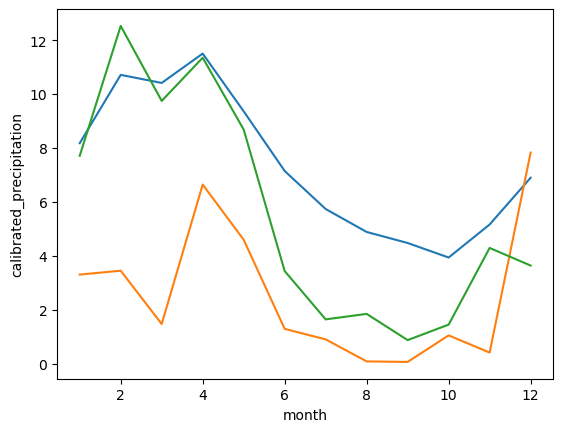

In [73]:
br_sa1_pr_month.plot()
ctl_pr_sa1_month.plot()
imerg_pr_sa1_month.plot()

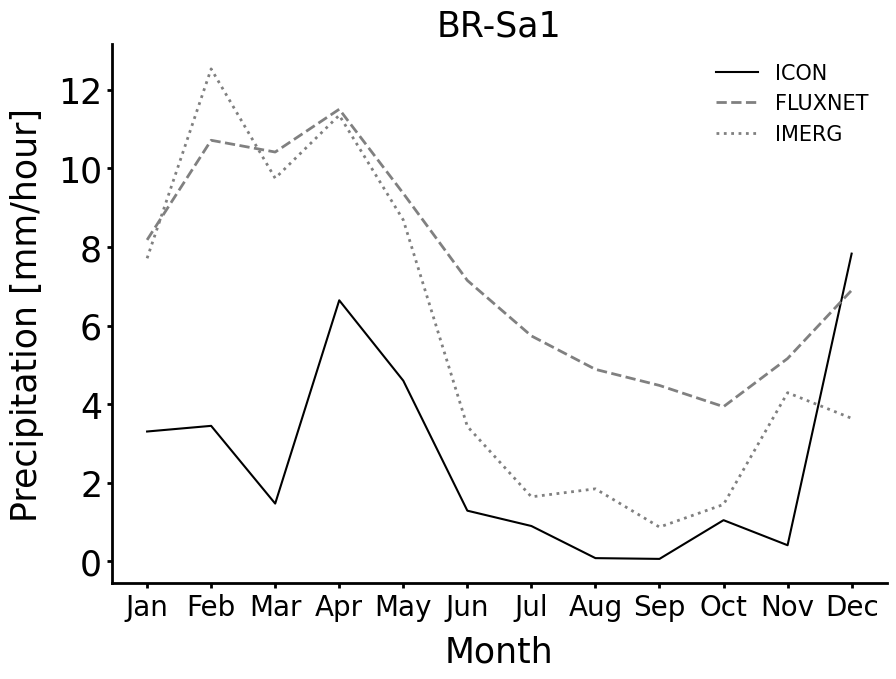

In [86]:
# Example plot
months = np.arange(1, 13)  # Exclude the first month for mean plot

fig, ax = plt.subplots(figsize=(10, 7))
#plt.plot(months, br_sh_mean[:], yerr=br_sh_std[:], fmt='o', color='black', ecolor='grey', capsize=10,  markersize='10')
plt.plot(months, ctl_pr_sa1_month[:], label='ICON', color='black')
plt.plot(months, br_sa1_pr_month[:], label='FLUXNET', color='grey', linestyle='--', linewidth=2)
plt.plot(months, imerg_pr_sa1_month[:], label='IMERG', color='grey', linestyle=':', linewidth=2)
#plt.ylabel('Temperature (K)')
#plt.title('Mean Precipitation with Standard Deviation')

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(np.linspace(1,12,12),months,fontsize=20)
plt.yticks(fontsize=25)
#plt.ylim(0, 50)

ax.set_ylabel('Precipitation [mm/hour]',fontsize=25, labelpad = 10)
ax.set_xlabel('Month',fontsize=25, labelpad = 10)

ax.xaxis.set_tick_params(width=2)
ax.yaxis.set_tick_params(width=2)

# The spines
plt.setp(ax.spines.values(), linewidth=2)

#plt.grid(True)
ax.spines[['right', 'top']].set_visible(False)
plt.legend(frameon =False, fontsize=15)
plt.title('BR-Sa1', fontsize=25)
plt.show()